<div align=center>
    <h1><b>Asesmen CLO Semester Genap 2024/2025</b></h1>
    <h1><b>Pemodelan dan Optimasi Lanjut</b></h1>
</div>

### Kelas : S2IF-48-01

### Anggota Kelompok
|Nama|NIM|
|----|---|
|Muhammad Abiya Makruf|203012420034|
|Muhammad Rafly Arjasubrata|203012420028|
|Nugroho Rahmanto|203012420029|

# **Soal 2**
Pada sebuah kota besar bernama Kota A, energi listrik termasuk kebutuhan pokok yang relatif mahal. Meningkatnya krisis energi, maka sangat diperlukan efisiensi penggunaan energi listrik, terutama untuk efisiensi biaya bagi perusahaan, guna menekan biaya produksi. Energi listrik diindikasikan bergantung terhadap parameter cuaca. Sebagai contoh, jika temperatur rendah (dingin), maka pemakaian Air Conditioner (AC) menjadi turun, atau jika sinar matahari sangat terik, maka pemakaian AC cendrung lebih meningkat.

Diketahui sebuah area mempunyai data cuaca dan data beban listrik pada tahun 2015-2020, sebagaimana yang terlihat pada gambar dibawah. Adapun data cuaca yang ada adalah:
1. Temperature atau suhu
2. Humidity atau kelembaban
3. Precipitation atau pengendapan, dan
4. Wind Speed atau kecepatan angin.

Data di atas dapat diunduh pada: https://1drv.ms/f/c/442ad6b0eca3d508/EnjAa6YiOgpJqgD1LfXg2j8BjeJ-bz6fRFPZE3HtrGAWCA?e=ITZ15q

### **Pertanyaan/Tugas**
1.  Hitunglah korelasi antara komponen cuaca yaitu temperature, humidity, precipitation, dan wind speed, terhadap electricity consumption.
    Catatan: gunakan R2 (Correlation Coefficient) untuk menghitung nilai correlation. Pada python, dapat digunakan:
    ```python
    from sklearn.metrics import r2_score
    r2_score = r2_score(target_data, predicted_data)
    ```

2.  Bangunlah model regresi linear antara komponen cuaca yang mempunyai correlation coefficient TERTINGGI (jika dibandingkan dengan electricity consumption) dengan electricity consumption dengan menggunakan Least Square Method ATAU Gradient Descent (lihat pertemuan 2, 3 dan 4).
    - Visualisasikan data antara komponen cuaca terhadap electricty consumption dalam bentuk Scatter plot
    - Visualisasikan hasil model regresi untuk poin (a) berupa garis linear dan tuliskan hasil model regresi (berupa persamaan garis)
    - bahas mengenai keakuratan dari model tsb

# **Jawaban No.2**

## Library

In [26]:
# Import library yang digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression


## Exploratory Data Analysis (EDA)

In [27]:
# Membaca file csv
df = pd.read_csv('Dataset/Electricity Load Data.csv')

# Menampilkan 5 data teratas
df.head()

,TIME,Temperature (C),Humidity (%),Precipitation (l/m^2),Wind Speed (m/s),Electricity Consumption (MWh)
0,2015-01-03 01:00:00,25.865259,0.018576,0.016174,21.850546,970.3450
1,2015-01-03 02:00:00,25.899255,0.018653,0.016418,22.166944,912.1755
2,2015-01-03 03:00:00,25.937280,0.018768,0.015480,22.454911,900.2688
3,2015-01-03 04:00:00,25.957544,0.018890,0.016273,22.110481,889.9538
4,2015-01-03 05:00:00,25.973840,0.018981,0.017281,21.186089,893.6865


In [28]:
# Menampilkan informasi dari dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   TIME                           48048 non-null  object 
 1   Temperature (C)                48048 non-null  float64
 2   Humidity (%)                   48048 non-null  float64
 3   Precipitation (l/m^2)          48048 non-null  float64
 4   Wind Speed (m/s)               48048 non-null  float64
 5   Electricity Consumption (MWh)  48048 non-null  float64
dtypes: float64(5), object(1)
memory usage: 2.2+ MB


In [29]:
# Menampilkan statistik deskriptif dari dataset
df.describe()

,Temperature (C),Humidity (%),Precipitation (l/m^2),Wind Speed (m/s),Electricity Consumption (MWh)
count,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000
mean,27.399111,0.018313,0.079979,13.391049,1182.868647
std,1.675462,0.001607,0.065589,7.295502,192.068896
min,22.953455,0.012054,0.000000,0.008979,85.192500
25%,26.160455,0.017236,0.026451,7.544958,1020.056900
50%,27.118051,0.018590,0.065201,12.182103,1168.427700
75%,28.558344,0.019521,0.117310,18.661282,1327.563950
max,35.039575,0.022690,0.521240,39.229726,1754.882000


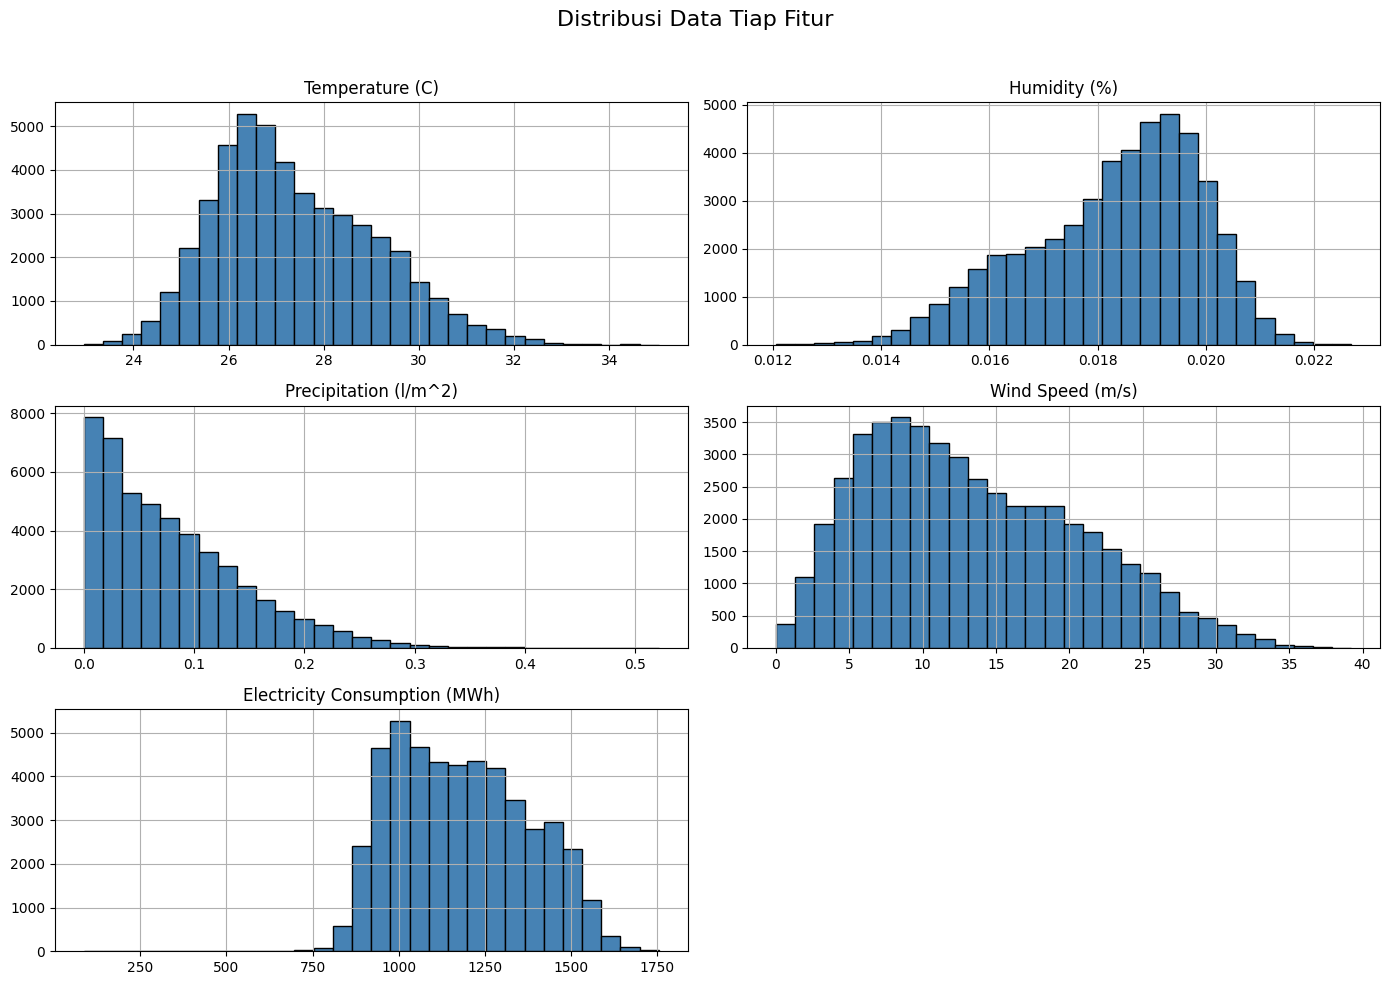

In [30]:
# Menampilkan distribusi data dari setiap fitur
df.hist(bins=30, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle("Distribusi Data Tiap Fitur", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

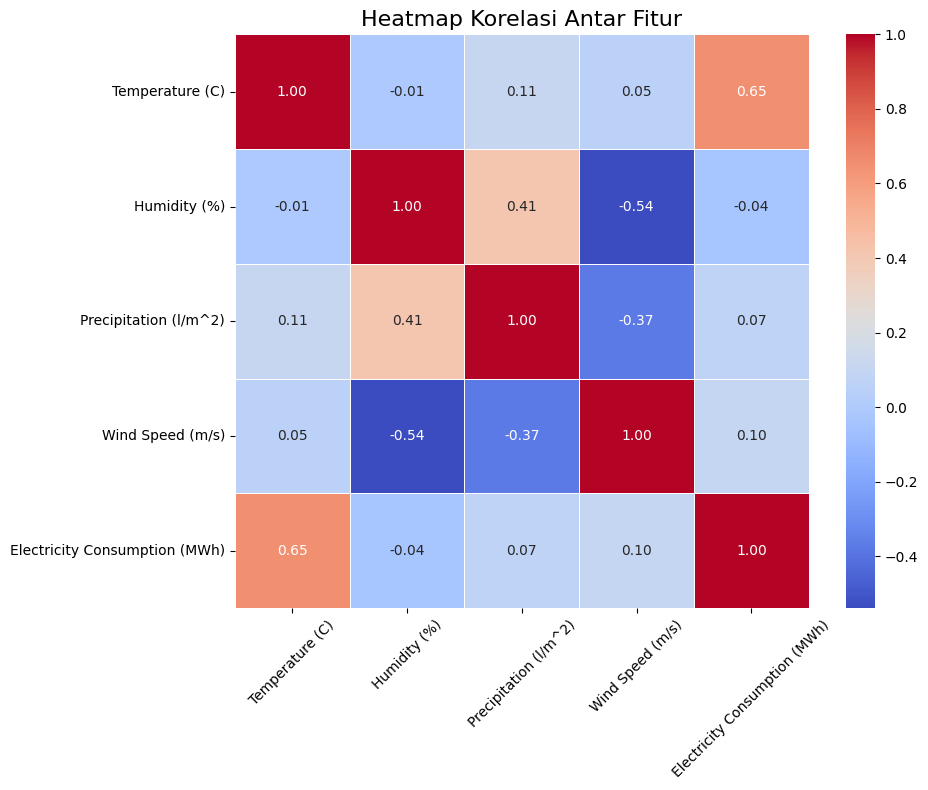

In [31]:
# Hitung matriks korelasi Pearson
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Heatmap Korelasi Antar Fitur", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [32]:
# Memperbaiki struktur data
df_clean = df.copy() # Membuat salinan dari dataframe asli
df_clean.drop(columns=['TIME'], inplace=True)  # Menghapus kolom yang tidak diperlukan
df_clean.columns = ['Temperature', 'Humidity ', 'Precipitation ', 'Wind_Speed', 'Electricity_Consumption'] # Mengganti nama kolom

# Menghapus baris yang memiliki nilai NaN
df_clean.dropna(inplace=True)

In [33]:
# Menampilkan data setelah dibersihkan
df_clean

,Temperature,Humidity,Precipitation,Wind_Speed,Electricity_Consumption
0,25.865259,0.018576,0.016174,21.850546,970.3450
1,25.899255,0.018653,0.016418,22.166944,912.1755
2,25.937280,0.018768,0.015480,22.454911,900.2688
3,25.957544,0.018890,0.016273,22.110481,889.9538
4,25.973840,0.018981,0.017281,21.186089,893.6865
...,...,...,...,...,...
48043,27.246545,0.020303,0.055511,9.289304,1128.5592
48044,27.099573,0.020395,0.053848,9.837504,1112.7488
48045,26.971155,0.020448,0.057251,10.262464,1081.5680
48046,26.867487,0.020464,0.064178,10.326567,1041.6240


## Jawaban Soal No 2.1

In [34]:
# Hitung nilai korelasi antara tiap fitur cuaca dengan Electricity_Consumption
corr_matrix[['Electricity Consumption (MWh)']].drop('Electricity Consumption (MWh)', axis=0).sort_values(by='Electricity Consumption (MWh)', ascending=False)

,Electricity Consumption (MWh)
Temperature (C),0.652811
Wind Speed (m/s),0.098435
Precipitation (l/m^2),0.073109
Humidity (%),-0.036706


Berdasarkan hasil dari output di atas maka komponen cuaca yang memiliki nilai korelasi tertinggi adalah Temperature dengan nilai 0.652811 diikuti oleh wind_Speed dengan nilai 0.098435, kemudian Precipitation dengan nilai 0.073109 dan terakhir Humidity dengan nilai -0.036706.

Temperature (C) dengan nilai 0.652811 menunjukan bahwa variabel tersebut memiliki hubungan linear dengan Electricity Consumption (MWh), visualisasi dari heatmap korelasi Pearson juga mendukung hal tersebut dimana hubungan antara Temperature dan Electricity Consumption memiliki nilai korelasi tertinggi dibandingkan variabel lainnya.

## Jawaban Soal No 2.2

In [35]:
# Membangun model regresi linear menggunakan gradient descent terhadap Temperature (fitur dengan R² tertinggi) dengan Electricity_Consumption

# Ambil fitur dan target (Temperature dan Electricity Consumption)
X = df_clean['Temperature'].values
y = df_clean['Electricity_Consumption'].values

# Normalisasi fitur (opsional, membantu konvergensi gradient descent)
X_norm = (X - np.mean(X)) / np.std(X)
y_norm = (y - np.mean(y)) / np.std(y)

# Inisialisasi parameter
m = 0  # slope
b = 0  # intercept
alpha = 0.01  # learning rate
epochs = 1000
n = len(X_norm)

# Gradient Descent
for _ in range(epochs):
    y_pred = m * X_norm + b
    error = y_pred - y_norm

    # Hitung turunan
    dm = (2/n) * np.dot(error, X_norm)
    db = (2/n) * np.sum(error)

    # Update parameter
    m -= alpha * dm
    b -= alpha * db

# Ubah kembali ke skala asli (denormalisasi)
slope = m * (np.std(y) / np.std(X))
intercept = np.mean(y) + b * np.std(y) - slope * np.mean(X)

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (b): {intercept:.4f}")

Slope (m): 74.8359
Intercept (b): -867.5690


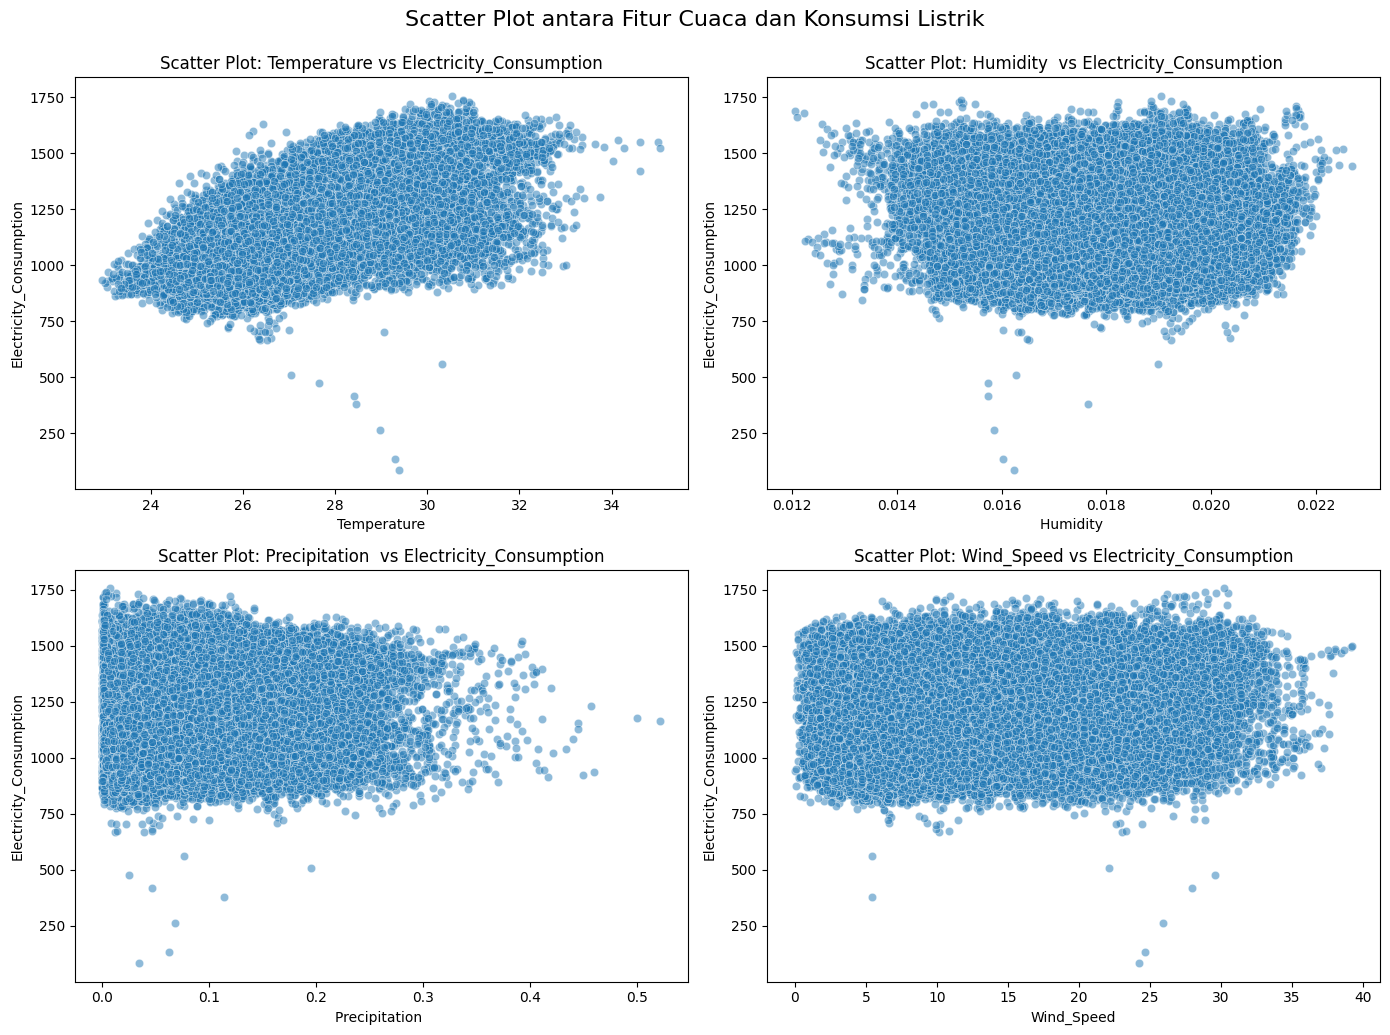

In [36]:
# A. Visualisasikan data antara komponen cuaca terhadap electricty consumption dalam bentuk Scatter plot
plt.figure(figsize=(14, 10))

# Membuat scatter plot untuk setiap fitur cuaca
weather_features = df_clean.columns[:-1]  # Semua kolom kecuali Electricity_Consumption
target = 'Electricity_Consumption'
for i, feature in enumerate(weather_features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=df_clean, x=feature, y=target, alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f'Scatter Plot: {feature} vs {target}')

plt.tight_layout()
plt.suptitle("Scatter Plot antara Fitur Cuaca dan Konsumsi Listrik", fontsize=16, y=1.03)
plt.show()

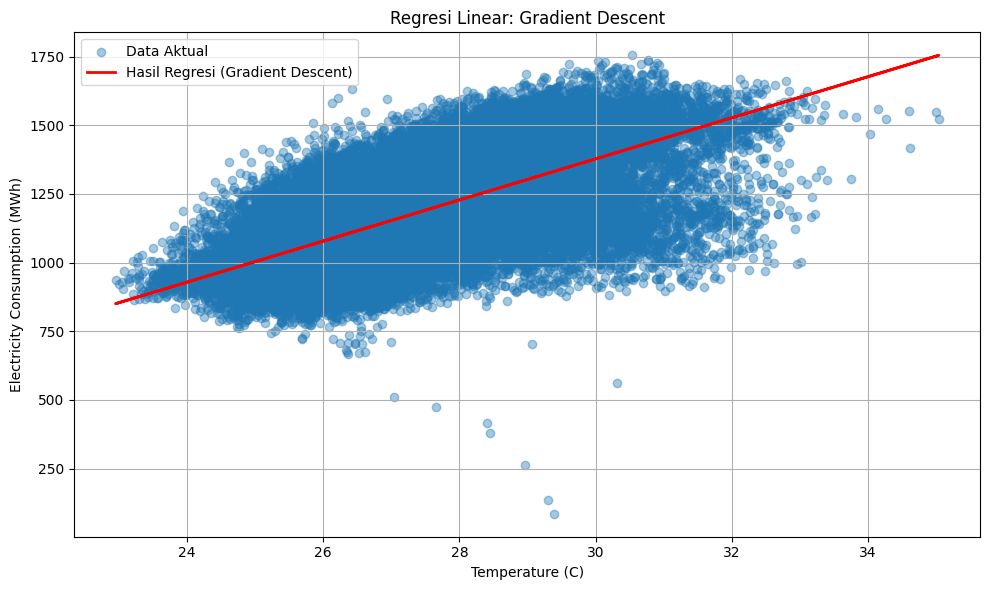

Persamaan Garis Regresi: Y = 74.8359 * X + -867.5690
Electricity Consumption = 74.8359 * Temperature + -867.5690


In [37]:
# B. Visualisasikan hasil model regresi untuk poin (a) berupa garis linear dan tuliskan hasil model regresi (berupa persamaan garis)
# Prediksi dengan hasil model
y_pred = slope * X + intercept

# Plot hasil
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data Aktual', alpha=0.4)
plt.plot(X, y_pred, color='red', label='Hasil Regresi (Gradient Descent)', linewidth=2)
plt.xlabel('Temperature (C)')
plt.ylabel('Electricity Consumption (MWh)')
plt.title('Regresi Linear: Gradient Descent')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Persamaan Garis Regresi: Y = {slope:.4f} * X + {intercept:.4f}")
print(f"Electricity Consumption = {slope:.4f} * Temperature + {intercept:.4f}")

In [38]:
# C. Membahas tentang hasil model regresi yang didapatkan

# Menghitung R², MAE, dan RMSE untuk model regresi yang dibangun
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"mean_absolute_error: {mae:.4f}")
print(f"root_mean_squared_error: {rmse:.4f}")

mean_absolute_error: 119.4088
root_mean_squared_error: 145.4946


1. **Mean Absolute Error (MAE): 119.41 MWh**

    MAE mengukur rata-rata selisih absolut antara nilai prediksi dan nilai aktual konsumsi listrik. Sehingga menunjukan:

    Rata-rata, model melakukan kesalahan prediksi sebesar ±119.41 MWh per jam.

    MAE tidak sensitif terhadap outlier, sehingga cocok untuk mengukur performa secara umum.

2. **Root Mean Squared Error (RMSE): 145.49 MWh**

    RMSE memberikan penalti lebih besar untuk error yang besar (karena dihitung kuadrat), sehingga menunjukkan:

    Terdapat beberapa prediksi yang jauh meleset dari nilai aktual, sehingga meningkatkan nilai RMSE.

    Nilai RMSE yang lebih tinggi dari MAE menandakan adanya outlier atau deviasi besar dalam sebagian data prediksi.

3. **R² Score: 0.426**

    Sekitar 42.6% variasi dalam konsumsi listrik bisa dijelaskan hanya dari suhu udara.


## Kesimpulan

Model regresi linier sederhana yang dibangun menggunakan suhu udara sebagai satu-satunya variabel prediktor mampu menjelaskan sekitar 42,6% variasi konsumsi listrik. Meskipun menunjukkan adanya hubungan linier sedang, nilai error yang cukup besar (MAE 119,4 MWh dan RMSE 145,5 MWh) mengindikasikan bahwa model ini belum cukup akurat untuk prediksi yang andal.